In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
df = pd.read_csv('../data/online_retail_II.csv', encoding='utf-8')
print(df.shape)
df.head()

(1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
# check columns - this dataset has different names
print(df.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [5]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [6]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [7]:
# drop missing Customer ID
# column name has a space in this dataset
df = df.dropna(subset=['Customer ID'])
print(df.shape)

(824364, 8)


In [8]:
# remove cancelled invoices (start with C)
df = df[~df['Invoice'].astype(str).str.startswith('C')]
print(df.shape)

(805620, 8)


In [9]:
# remove bad rows
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]
print(df.shape)

(805549, 8)


In [10]:
# fix dtypes
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Customer ID'] = df['Customer ID'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 805549 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805549 non-null  object        
 1   StockCode    805549 non-null  object        
 2   Description  805549 non-null  object        
 3   Quantity     805549 non-null  int64         
 4   InvoiceDate  805549 non-null  datetime64[ns]
 5   Price        805549 non-null  float64       
 6   Customer ID  805549 non-null  int32         
 7   Country      805549 non-null  object        
dtypes: datetime64[ns](1), float64(1), int32(1), int64(1), object(4)
memory usage: 52.2+ MB


In [11]:
# Price = UnitPrice in this dataset
df['TotalSpend'] = df['Quantity'] * df['Price']
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalSpend
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [12]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID,TotalSpend
count,805549.000000,805549,805549.000000,805549.000000,805549.000000
mean,13.290522,2011-01-02 10:24:44.106814464,3.206561,15331.954970,22.026505
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,0.001000
25%,2.000000,2010-07-07 12:08:00,1.250000,13982.000000,4.950000
50%,5.000000,2010-12-03 15:10:00,1.950000,15271.000000,11.850000
75%,12.000000,2011-07-28 13:05:00,3.750000,16805.000000,19.500000
max,80995.000000,2011-12-09 12:50:00,10953.500000,18287.000000,168469.600000
std,143.634088,NaN,29.199173,1696.737039,224.041928


### plots

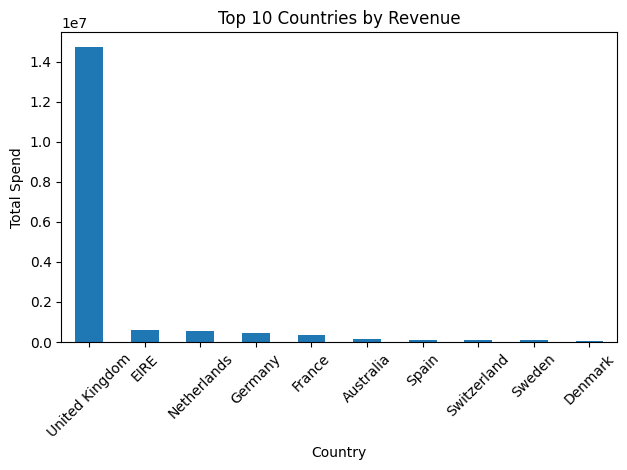

In [13]:
top_countries = df.groupby('Country')['TotalSpend'].sum().sort_values(ascending=False).head(10)
top_countries.plot(kind='bar')
plt.title('Top 10 Countries by Revenue')
plt.ylabel('Total Spend')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

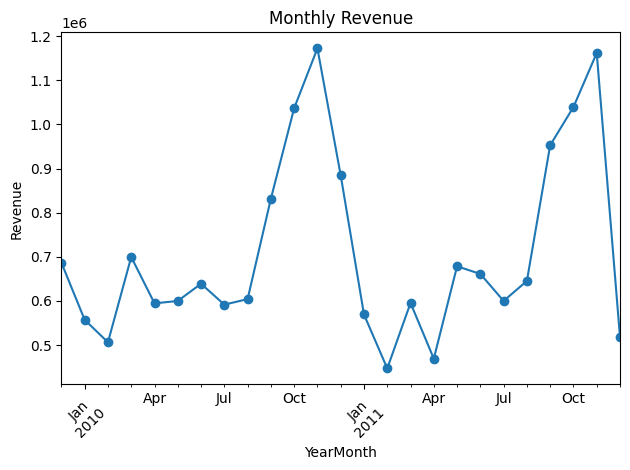

In [14]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly = df.groupby('YearMonth')['TotalSpend'].sum()
monthly.plot(marker='o')
plt.title('Monthly Revenue')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### RFM features
- Recency = days since last purchase
- Frequency = number of unique invoices
- Monetary = total amount spent

In [15]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Invoice',     'nunique'),
    Monetary  = ('TotalSpend',  'sum')
).reset_index()

# rename to remove the space - easier to use later
rfm.rename(columns={'Customer ID': 'CustomerID'}, inplace=True)
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,5633.32
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40


In [16]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,201.331916,6.289384,3018.616737
std,1715.572666,209.338707,13.009406,14737.731040
min,12346.000000,1.000000,1.000000,2.950000
25%,13833.250000,26.000000,1.000000,348.762500
50%,15314.500000,96.000000,3.000000,898.915000
75%,16797.750000,380.000000,7.000000,2307.090000
max,18287.000000,739.000000,398.000000,608821.650000


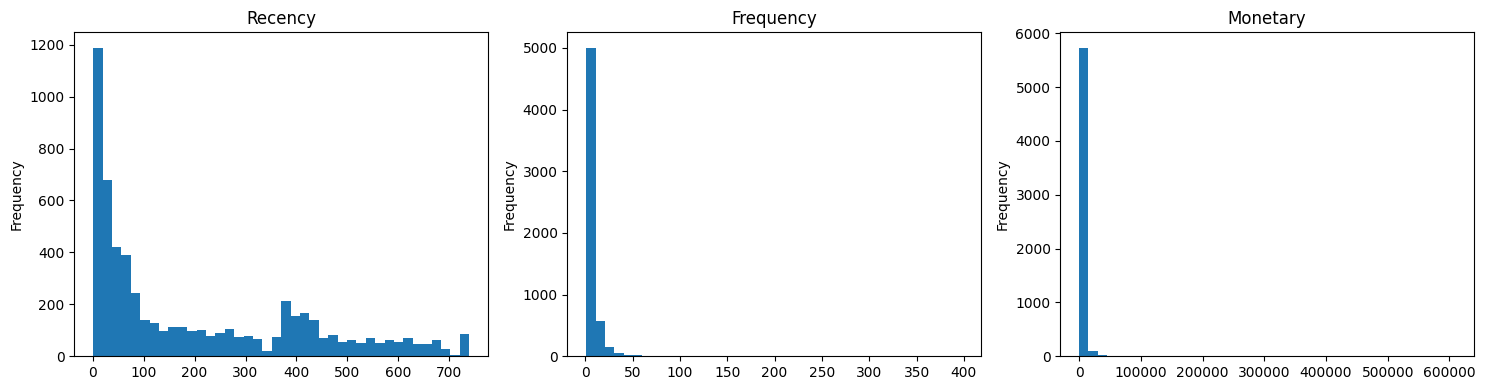

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
rfm['Recency'].plot(kind='hist', bins=40, ax=axes[0], title='Recency')
rfm['Frequency'].plot(kind='hist', bins=40, ax=axes[1], title='Frequency')
rfm['Monetary'].plot(kind='hist', bins=40, ax=axes[2], title='Monetary')
plt.tight_layout()
plt.show()

In [18]:
print(rfm['Monetary'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

0.25      348.7625
0.50      898.9150
0.75     2307.0900
0.90     5595.3650
0.95     9535.3360
0.99    29730.4202
Name: Monetary, dtype: float64


In [19]:
# cap outliers at 99th percentile
for col in ['Recency', 'Frequency', 'Monetary']:
    cap = rfm[col].quantile(0.99)
    rfm[col] = rfm[col].clip(upper=cap)

rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,201.257741,5.785471,2352.912286
std,1715.572666,209.151082,7.630332,4338.246317
min,12346.000000,1.000000,1.000000,2.950000
25%,13833.250000,26.000000,1.000000,348.762500
50%,15314.500000,96.000000,3.000000,898.915000
75%,16797.750000,380.000000,7.000000,2307.090000
max,18287.000000,726.000000,46.000000,29730.420200


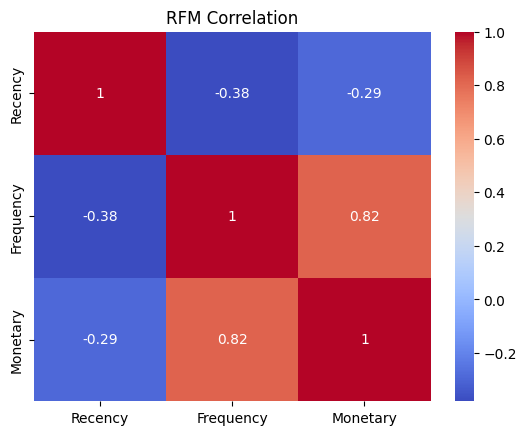

In [20]:
sns.heatmap(rfm[['Recency', 'Frequency', 'Monetary']].corr(), annot=True, cmap='coolwarm')
plt.title('RFM Correlation')
plt.show()

In [21]:
# add country back for dashboard filters
country_map = df.groupby('Customer ID')['Country'].first().reset_index()
country_map.rename(columns={'Customer ID': 'CustomerID'}, inplace=True)
rfm = rfm.merge(country_map, on='CustomerID', how='left')
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Country
0,12346,326,12,29730.4202,United Kingdom
1,12347,2,8,5633.3200,Iceland
2,12348,75,5,2019.4000,Finland
3,12349,19,4,4428.6900,Italy
4,12350,310,1,334.4000,Norway


In [22]:
os.makedirs('../data', exist_ok=True)
rfm.to_csv('../data/cleaned.csv', index=False)
print('saved → ../data/cleaned.csv')
print(rfm.shape)

saved → ../data/cleaned.csv
(5878, 5)
